In [ ]:
## import numpy as np # linear algebra
import pandas as pd
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt
np.random.seed(0)
#from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import make_column_transformer
#from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor
from sklearn.cluster import KMeans
from sklearn.model_selection import cross_val_score
from sklearn.feature_selection import mutual_info_regression
from sklearn.decomposition import PCA
import math
from sklearn.linear_model import LogisticRegression
def score_dataset(X, y, model = LogisticRegression(C=0.01, penalty="l2",
    random_state=0,
    class_weight="balanced",
    solver="liblinear",
)):
    score = cross_val_score(model, X, y, cv=5, scoring="roc_auc")
    print(score.mean())
def apply_pca(X, standardize=True):
    # Standardize
    if standardize:
        X = (X - X.mean(axis=0)) / X.std(axis=0)
    # Create principal components
    pca = PCA()
    X_pca = pca.fit_transform(X)
    # Convert to dataframe
    component_names = [f"PC{i+1}" for i in range(X_pca.shape[1])]
    X_pca = pd.DataFrame(X_pca, columns=component_names)
    # Create loadings
    loadings = pd.DataFrame(
        pca.components_.T,  # transpose the matrix of loadings
        columns=component_names,  # so the columns are the principal components
        index=X.columns,  # and the rows are the original features
    )
    return pca, X_pca, loadings

In [2]:
from pathlib import Path
from warnings import simplefilter

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LinearRegression
from statsmodels.tsa.deterministic import CalendarFourier, DeterministicProcess
def plot_periodogram(ts, detrend='linear', ax=None):
    from scipy.signal import periodogram
    fs = pd.Timedelta("365D") / pd.Timedelta("1D")
    freqencies, spectrum = periodogram(
        ts,
        fs=fs,
        detrend=detrend,
        window="boxcar",
        scaling='spectrum',
    )
    if ax is None:
        _, ax = plt.subplots()
    ax.step(freqencies, spectrum, color="purple")
    ax.set_xscale("log")
    ax.set_xticks([1, 2, 4, 6, 12, 26, 52, 104])
    ax.set_xticklabels(
        [
            "Annual (1)",
            "Semiannual (2)",
            "Quarterly (4)",
            "Bimonthly (6)",
            "Monthly (12)",
            "Biweekly (26)",
            "Weekly (52)",
            "Semiweekly (104)",
        ],
        rotation=30,
    )
    ax.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))
    ax.set_ylabel("Variance")
    ax.set_title("Periodogram")
    return ax


In [3]:
rain_file_path = 'data/train2_1.csv'
rain_data = pd.read_csv(rain_file_path)
test_file_path = "data/test.csv"
test_data = pd.read_csv(test_file_path)

In [4]:
test_data.fillna(value=160, inplace=True)

In [5]:
rain_data["year"] = (rain_data.index + 1) / 365
rain_data["year"] = np.ceil(rain_data.year)
rain_data = rain_data.astype({'year': 'int64'})

In [6]:
rain_data.year = rain_data.year.replace(8, 7)

In [7]:
test_data["year"] = (test_data.index + 1) / 365
test_data["year"] = np.ceil(test_data.year)
test_data["year"] = test_data["year"] + 7
test_data = test_data.astype({'year': 'int64'})
rain_data["time"] = np.arange(len(rain_data.index))

In [8]:
test_data["time"] = np.arange(len(test_data.index)) + 2556

In [9]:
rain_data

,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed,rainfall,year,time
0,1025.9,19.9,18.3,16.8,13.1,72.0,49.0,9.3,80.0,26.3,1,1,0
1,1022.0,21.7,18.9,17.2,15.6,81.0,83.0,0.6,50.0,15.3,1,1,1
2,1019.7,20.3,19.3,18.0,18.4,95.0,91.0,0.0,40.0,14.2,1,1,2
3,1018.9,22.3,20.6,19.1,18.8,90.0,88.0,1.0,50.0,16.9,1,1,3
4,1015.9,21.3,20.7,20.2,19.9,95.0,81.0,0.0,40.0,13.7,1,1,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2551,1014.6,23.2,20.6,19.1,19.9,97.0,88.0,0.1,40.0,22.1,1,7,2551
2552,1012.4,17.2,17.3,16.3,15.3,91.0,88.0,0.0,50.0,35.3,1,7,2552
2553,1013.3,19.0,16.3,14.3,12.6,79.0,79.0,5.0,40.0,32.9,1,7,2553
2554,1022.3,16.4,15.2,13.8,14.7,92.0,93.0,0.1,40.0,18.0,1,7,2554


In [10]:
>>> from statsmodels.tsa.deterministic import DeterministicProcess
>>> from pandas import date_range
>>> rain_data.index = date_range("2013-1-1", freq="D", periods=2556)
test_data.index = date_range("2020-1-1", freq="D", periods=730)
rain_data

,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed,rainfall,year,time
2013-01-01,1025.9,19.9,18.3,16.8,13.1,72.0,49.0,9.3,80.0,26.3,1,1,0
2013-01-02,1022.0,21.7,18.9,17.2,15.6,81.0,83.0,0.6,50.0,15.3,1,1,1
2013-01-03,1019.7,20.3,19.3,18.0,18.4,95.0,91.0,0.0,40.0,14.2,1,1,2
2013-01-04,1018.9,22.3,20.6,19.1,18.8,90.0,88.0,1.0,50.0,16.9,1,1,3
2013-01-05,1015.9,21.3,20.7,20.2,19.9,95.0,81.0,0.0,40.0,13.7,1,1,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2019-12-27,1014.6,23.2,20.6,19.1,19.9,97.0,88.0,0.1,40.0,22.1,1,7,2551
2019-12-28,1012.4,17.2,17.3,16.3,15.3,91.0,88.0,0.0,50.0,35.3,1,7,2552
2019-12-29,1013.3,19.0,16.3,14.3,12.6,79.0,79.0,5.0,40.0,32.9,1,7,2553
2019-12-30,1022.3,16.4,15.2,13.8,14.7,92.0,93.0,0.1,40.0,18.0,1,7,2554


In [11]:
def seasonal_plot(X, y, period, freq, ax=None):
    if ax is None:
        _, ax = plt.subplots()
    palette = sns.color_palette("husl", n_colors=X[period].nunique(),)
    ax = sns.lineplot(
        x=freq,
        y=y,
        hue=period,
        data=X,
        ci=False,
        ax=ax,
        palette=palette,
        legend=False,
    )
    ax.set_title(f"Seasonal Plot ({period}/{freq})")
    for line, name in zip(ax.lines, X[period].unique()):
        y_ = line.get_ydata()[-1]
        ax.annotate(
            name,
            xy=(1, y_),
            xytext=(6, 0),
            color=line.get_color(),
            xycoords=ax.get_yaxis_transform(),
            textcoords="offset points",
            size=14,
            va="center",
        )
    return ax

In [12]:
X = rain_data.copy()

# days within a week
X["day"] = X.index.dayofweek  # the x-axis (freq)
X["month"] = X.index.month  # the seasonal period (period)

# days within a year
#X["month"] = X.index.dayofyear
X["year"] = X.index.year
X

,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed,rainfall,year,time,day,month
2013-01-01,1025.9,19.9,18.3,16.8,13.1,72.0,49.0,9.3,80.0,26.3,1,2013,0,1,1
2013-01-02,1022.0,21.7,18.9,17.2,15.6,81.0,83.0,0.6,50.0,15.3,1,2013,1,2,1
2013-01-03,1019.7,20.3,19.3,18.0,18.4,95.0,91.0,0.0,40.0,14.2,1,2013,2,3,1
2013-01-04,1018.9,22.3,20.6,19.1,18.8,90.0,88.0,1.0,50.0,16.9,1,2013,3,4,1
2013-01-05,1015.9,21.3,20.7,20.2,19.9,95.0,81.0,0.0,40.0,13.7,1,2013,4,5,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2019-12-27,1014.6,23.2,20.6,19.1,19.9,97.0,88.0,0.1,40.0,22.1,1,2019,2551,4,12
2019-12-28,1012.4,17.2,17.3,16.3,15.3,91.0,88.0,0.0,50.0,35.3,1,2019,2552,5,12
2019-12-29,1013.3,19.0,16.3,14.3,12.6,79.0,79.0,5.0,40.0,32.9,1,2019,2553,6,12
2019-12-30,1022.3,16.4,15.2,13.8,14.7,92.0,93.0,0.1,40.0,18.0,1,2019,2554,0,12


<Axes: title={'center': 'Periodogram'}, ylabel='Variance'>

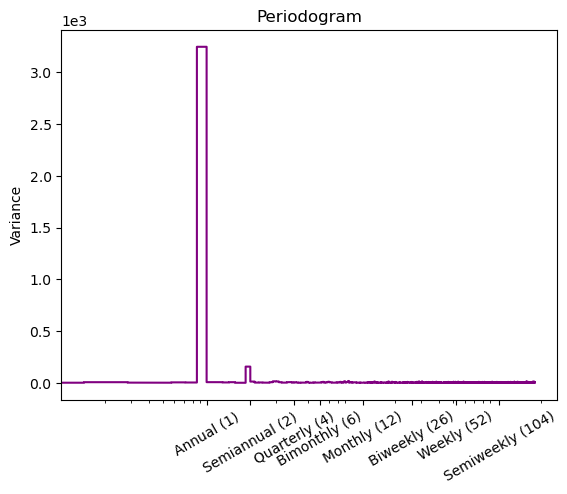

In [13]:

plot_periodogram(rain_data.winddirection)

In [14]:
from statsmodels.tsa.deterministic import CalendarFourier, DeterministicProcess

fourier = CalendarFourier(freq="A", order=1)  # 10 sin/cos pairs for "A"nnual seasonality

dp = DeterministicProcess(
    index=rain_data.index,
    constant=True,               # dummy feature for bias (y-intercept)
    order=1,                     # trend (order 1 means linear)
    seasonal=False,               # weekly seasonality (indicators)
    additional_terms=[fourier],  # annual seasonality (fourier)
    drop=True,                   # drop terms to avoid collinearity
)

X = dp.in_sample()
Z = dp.out_of_sample(730)

/opt/anaconda3/envs/DataScience/lib/python3.11/site-packages/statsmodels/tsa/deterministic.py:569: FutureWarning: 'A' is deprecated and will be removed in a future version, please use 'YE' instead.
  index = pd.date_range("2020-01-01", freq=freq, periods=1)


In [15]:
Z

,const,trend,"sin(1,freq=YE-DEC)","cos(1,freq=YE-DEC)"
2020-01-01,1.0,2557.0,0.000000,1.000000
2020-01-02,1.0,2558.0,0.017166,0.999853
2020-01-03,1.0,2559.0,0.034328,0.999411
2020-01-04,1.0,2560.0,0.051479,0.998674
2020-01-05,1.0,2561.0,0.068615,0.997643
...,...,...,...,...
2021-12-26,1.0,3282.0,-0.103102,0.994671
2021-12-27,1.0,3283.0,-0.085965,0.996298
2021-12-28,1.0,3284.0,-0.068802,0.997630
2021-12-29,1.0,3285.0,-0.051620,0.998667


In [16]:
X

,const,trend,"sin(1,freq=YE-DEC)","cos(1,freq=YE-DEC)"
2013-01-01,1.0,1.0,0.000000,1.000000
2013-01-02,1.0,2.0,0.017213,0.999852
2013-01-03,1.0,3.0,0.034422,0.999407
2013-01-04,1.0,4.0,0.051620,0.998667
2013-01-05,1.0,5.0,0.068802,0.997630
...,...,...,...,...
2019-12-27,1.0,2552.0,-0.085965,0.996298
2019-12-28,1.0,2553.0,-0.068802,0.997630
2019-12-29,1.0,2554.0,-0.051620,0.998667
2019-12-30,1.0,2555.0,-0.034422,0.999407


In [17]:
rain_data = rain_data.join(X)

In [18]:
test_data = test_data.join(Z)

In [19]:
X = rain_data.drop(labels="rainfall", axis=1)
y = rain_data.rainfall
X_test = test_data
mi_scores = mutual_info_regression(X, y)
mi_scores = pd.Series(mi_scores, name="MI Scores", index=X.columns)
mi_scores = mi_scores.sort_values(ascending=False)
mi_scores

cloud                 0.197325
sunshine              0.169987
humidity              0.129954
trend                 0.082442
time                  0.080197
maxtemp               0.042850
temparature           0.028157
sin(1,freq=YE-DEC)    0.024842
cos(1,freq=YE-DEC)    0.019980
dewpoint              0.018562
year                  0.016472
mintemp               0.012524
windspeed             0.011343
pressure              0.010367
winddirection         0.003952
const                 0.000000
Name: MI Scores, dtype: float64

In [20]:
model = LinearRegression().fit(X, y)
y_pred = model.predict(X)

Text(0.5, 0, 'time')

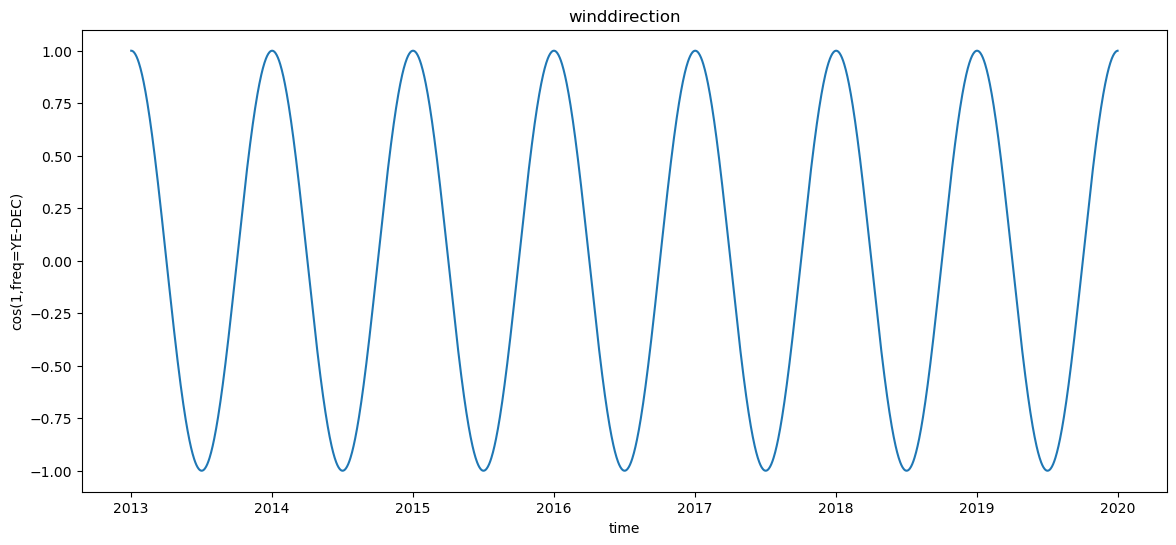

In [21]:
## Set the width and height of the figure
plt.figure(figsize=(14,6))

# Add title
plt.title("winddirection")

# Line chart showing daily global streams of 'Shape of You'
#sns.lineplot(x=test_data['day'], y=test_data["winddirection"])

# Line chart showing daily global streams of 'Despacito'
sns.lineplot(x=rain_data.index, y=rain_data["cos(1,freq=YE-DEC)"])

# Add label for horizontal axis
plt.xlabel("time")

Text(0.5, 0, 'time')

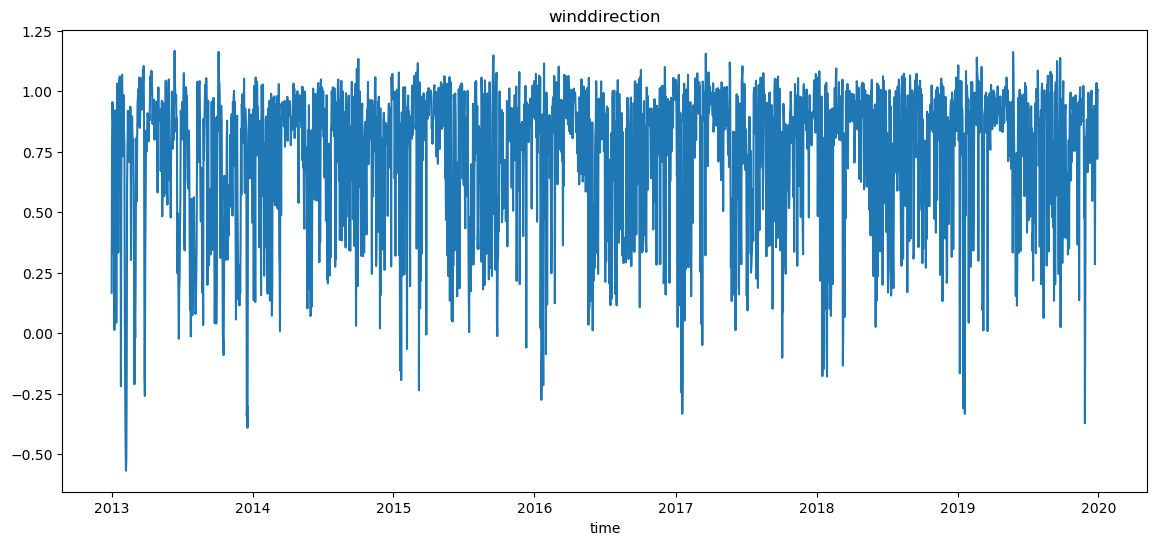

In [22]:
## Set the width and height of the figure
plt.figure(figsize=(14,6))

# Add title
plt.title("winddirection")

# Line chart showing daily global streams of 'Shape of You'
#sns.lineplot(x=test_data['day'], y=test_data["winddirection"])

# Line chart showing daily global streams of 'Despacito'
sns.lineplot(x=rain_data.index, y=y_pred)

# Add label for horizontal axis
plt.xlabel("time")

Text(0.5, 0, 'time')

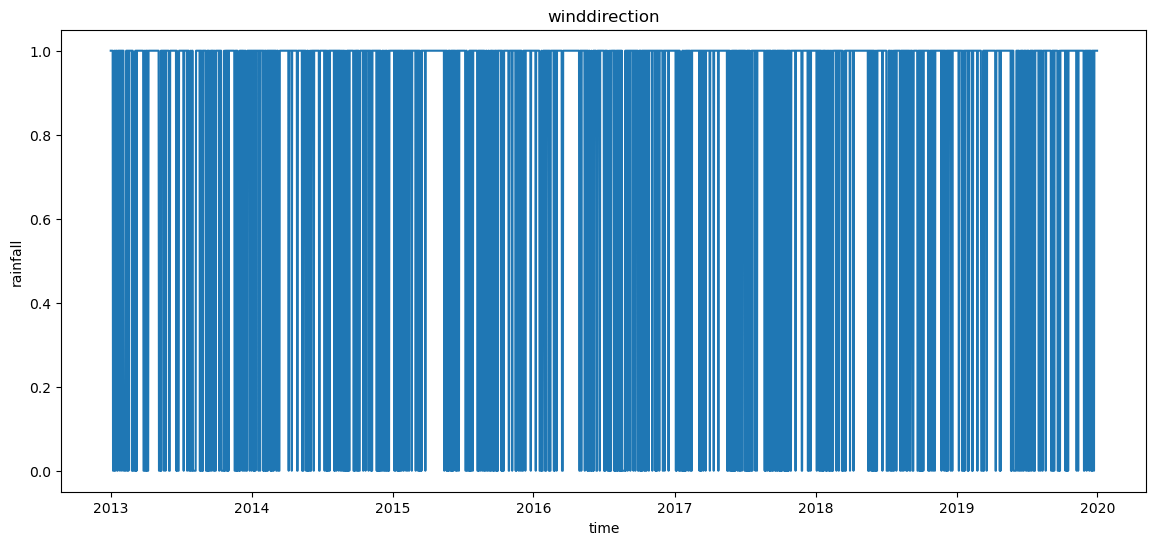

In [23]:
## Set the width and height of the figure
plt.figure(figsize=(14,6))

# Add title
plt.title("winddirection")
sns.lineplot(x=rain_data.index, y=rain_data.rainfall)
plt.xlabel("time")

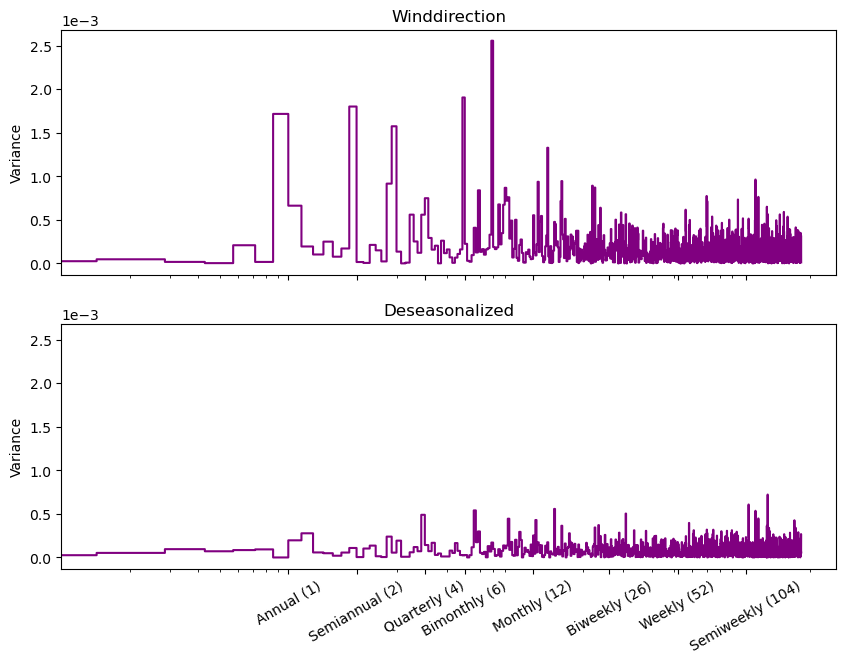

In [24]:
y_deseason = y - y_pred

fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, sharey=True, figsize=(10, 7))
ax1 = plot_periodogram(y, ax=ax1)
ax1.set_title("Winddirection")
ax2 = plot_periodogram(y_deseason, ax=ax2);
ax2.set_title("Deseasonalized");

<Axes: xlabel='time', ylabel='cloud'>

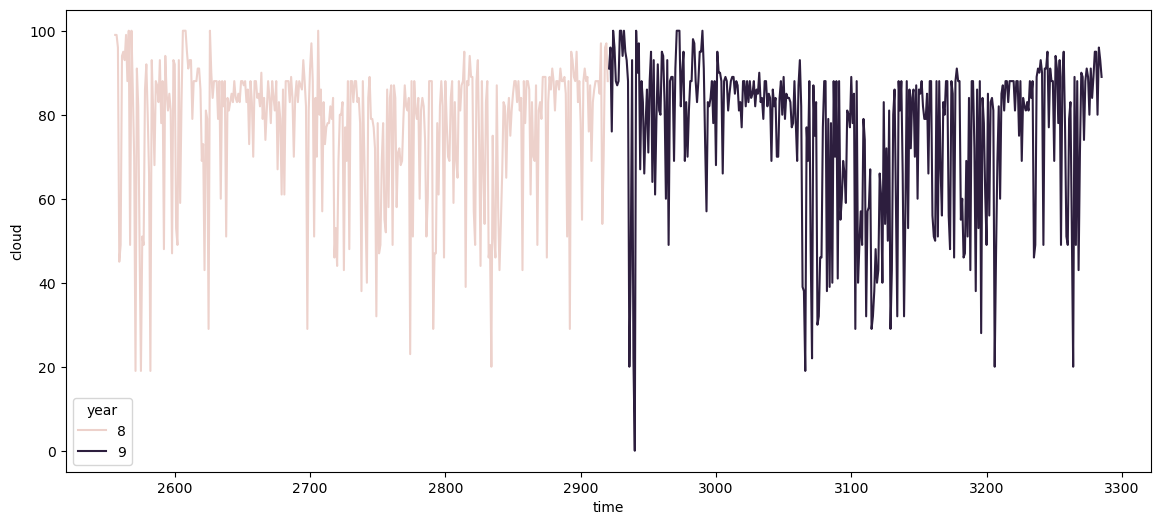

In [25]:
## Set the width and height of the figure
plt.figure(figsize=(14,6))
sns.lineplot(x=test_data['time'], y=test_data["cloud"], hue=test_data["year"])

<Axes: xlabel='time', ylabel='winddirection'>

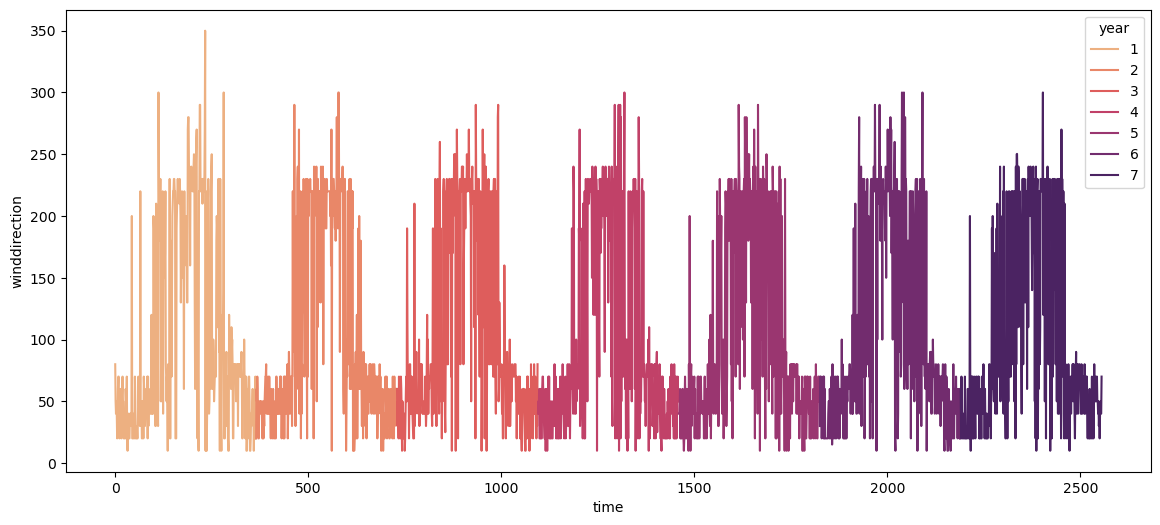

In [26]:
## Set the width and height of the figure
plt.figure(figsize=(14,6))
sns.lineplot(x=rain_data['time'], y=rain_data["winddirection"], hue=rain_data["year"], palette="flare")

In [27]:
rain_data

,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed,rainfall,year,time,const,trend,"sin(1,freq=YE-DEC)","cos(1,freq=YE-DEC)"
2013-01-01,1025.9,19.9,18.3,16.8,13.1,72.0,49.0,9.3,80.0,26.3,1,1,0,1.0,1.0,0.000000,1.000000
2013-01-02,1022.0,21.7,18.9,17.2,15.6,81.0,83.0,0.6,50.0,15.3,1,1,1,1.0,2.0,0.017213,0.999852
2013-01-03,1019.7,20.3,19.3,18.0,18.4,95.0,91.0,0.0,40.0,14.2,1,1,2,1.0,3.0,0.034422,0.999407
2013-01-04,1018.9,22.3,20.6,19.1,18.8,90.0,88.0,1.0,50.0,16.9,1,1,3,1.0,4.0,0.051620,0.998667
2013-01-05,1015.9,21.3,20.7,20.2,19.9,95.0,81.0,0.0,40.0,13.7,1,1,4,1.0,5.0,0.068802,0.997630
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2019-12-27,1014.6,23.2,20.6,19.1,19.9,97.0,88.0,0.1,40.0,22.1,1,7,2551,1.0,2552.0,-0.085965,0.996298
2019-12-28,1012.4,17.2,17.3,16.3,15.3,91.0,88.0,0.0,50.0,35.3,1,7,2552,1.0,2553.0,-0.068802,0.997630
2019-12-29,1013.3,19.0,16.3,14.3,12.6,79.0,79.0,5.0,40.0,32.9,1,7,2553,1.0,2554.0,-0.051620,0.998667
2019-12-30,1022.3,16.4,15.2,13.8,14.7,92.0,93.0,0.1,40.0,18.0,1,7,2554,1.0,2555.0,-0.034422,0.999407


In [28]:
X = X.drop(labels = ("trend"), axis=1)
score_dataset(X, y)

0.8913542602562814


In [29]:
test_data

,id,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed,year,time,const,trend,"sin(1,freq=YE-DEC)","cos(1,freq=YE-DEC)"
2020-01-01,2190,1,1019.5,17.5,15.8,12.7,14.9,96.0,99.0,0.0,50.0,24.3,8,2556,1.0,2557.0,0.000000,1.000000
2020-01-02,2191,2,1016.5,17.5,16.5,15.8,15.1,97.0,99.0,0.0,50.0,35.3,8,2557,1.0,2558.0,0.017166,0.999853
2020-01-03,2192,3,1023.9,11.2,10.4,9.4,8.9,86.0,96.0,0.0,40.0,16.9,8,2558,1.0,2559.0,0.034328,0.999411
2020-01-04,2193,4,1022.9,20.6,17.3,15.2,9.5,75.0,45.0,7.1,20.0,50.6,8,2559,1.0,2560.0,0.051479,0.998674
2020-01-05,2194,5,1022.2,16.1,13.8,6.4,4.3,68.0,49.0,9.2,20.0,19.4,8,2560,1.0,2561.0,0.068615,0.997643
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-12-26,2915,361,1020.8,18.2,17.6,16.1,13.7,96.0,95.0,0.0,20.0,34.3,9,3281,1.0,3282.0,-0.103102,0.994671
2021-12-27,2916,362,1011.7,23.2,18.1,16.0,16.0,78.0,80.0,1.6,40.0,25.2,9,3282,1.0,3283.0,-0.085965,0.996298
2021-12-28,2917,363,1022.7,21.0,18.5,17.0,15.5,92.0,96.0,0.0,50.0,21.9,9,3283,1.0,3284.0,-0.068802,0.997630
2021-12-29,2918,364,1014.4,21.0,20.0,19.7,19.8,94.0,93.0,0.0,50.0,39.5,9,3284,1.0,3285.0,-0.051620,0.998667


In [30]:
test_data.columns

Index(['id', 'day', 'pressure', 'maxtemp', 'temparature', 'mintemp',
       'dewpoint', 'humidity', 'cloud', 'sunshine', 'winddirection',
       'windspeed', 'year', 'time', 'const', 'trend', 'sin(1,freq=YE-DEC)',
       'cos(1,freq=YE-DEC)'],
      dtype='object')

In [31]:
X.columns

Index(['pressure', 'maxtemp', 'temparature', 'mintemp', 'dewpoint', 'humidity',
       'cloud', 'sunshine', 'winddirection', 'windspeed', 'year', 'time',
       'const', 'sin(1,freq=YE-DEC)', 'cos(1,freq=YE-DEC)'],
      dtype='object')

In [32]:
X_test.drop(["id", "day", "const", "trend"], axis=1, inplace=True)
X.drop(["const"], axis=1, inplace=True)
score_dataset(X, y)

0.8913581866232049


In [33]:
mi_scores = mutual_info_regression(X, y)
mi_scores = pd.Series(mi_scores, name="MI Scores", index=X.columns)
mi_scores = mi_scores.sort_values(ascending=False)
mi_scores

cloud                 0.230436
sunshine              0.184097
humidity              0.124620
time                  0.083915
sin(1,freq=YE-DEC)    0.034390
dewpoint              0.032310
year                  0.028560
temparature           0.028062
maxtemp               0.025750
windspeed             0.019045
cos(1,freq=YE-DEC)    0.018525
winddirection         0.013391
pressure              0.006366
mintemp               0.000000
Name: MI Scores, dtype: float64

In [34]:
cols = ["cloud", "sunshine", "humidity", "temparature", "dewpoint", "winddirection"]
cols_for_scaling = X.loc[:, cols]
cols_for_scaling

,cloud,sunshine,humidity,temparature,dewpoint,winddirection
2013-01-01,49.0,9.3,72.0,18.3,13.1,80.0
2013-01-02,83.0,0.6,81.0,18.9,15.6,50.0
2013-01-03,91.0,0.0,95.0,19.3,18.4,40.0
2013-01-04,88.0,1.0,90.0,20.6,18.8,50.0
2013-01-05,81.0,0.0,95.0,20.7,19.9,40.0
...,...,...,...,...,...,...
2019-12-27,88.0,0.1,97.0,20.6,19.9,40.0
2019-12-28,88.0,0.0,91.0,17.3,15.3,50.0
2019-12-29,79.0,5.0,79.0,16.3,12.6,40.0
2019-12-30,93.0,0.1,92.0,15.2,14.7,40.0


In [35]:
from sklearn.preprocessing import MinMaxScaler

ms = MinMaxScaler()

X_scaled = ms.fit_transform(cols_for_scaling)
X_scaled = pd.DataFrame(X_scaled, columns=[cols])
X_test_scaled = ms.fit_transform(cols_for_scaling)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=[cols])

X_scaled

,cloud,sunshine,humidity,temparature,dewpoint,winddirection
0,0.49,0.768595,0.580645,0.487273,0.498155,0.205882
1,0.83,0.049587,0.725806,0.509091,0.590406,0.117647
2,0.91,0.000000,0.951613,0.523636,0.693727,0.088235
3,0.88,0.082645,0.870968,0.570909,0.708487,0.117647
4,0.81,0.000000,0.951613,0.574545,0.749077,0.088235
...,...,...,...,...,...,...
2551,0.88,0.008264,0.983871,0.570909,0.749077,0.088235
2552,0.88,0.000000,0.887097,0.450909,0.579336,0.117647
2553,0.79,0.413223,0.693548,0.414545,0.479705,0.088235
2554,0.93,0.008264,0.903226,0.374545,0.557196,0.088235


In [36]:
X

,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed,year,time,"sin(1,freq=YE-DEC)","cos(1,freq=YE-DEC)"
2013-01-01,1025.9,19.9,18.3,16.8,13.1,72.0,49.0,9.3,80.0,26.3,1,0,0.000000,1.000000
2013-01-02,1022.0,21.7,18.9,17.2,15.6,81.0,83.0,0.6,50.0,15.3,1,1,0.017213,0.999852
2013-01-03,1019.7,20.3,19.3,18.0,18.4,95.0,91.0,0.0,40.0,14.2,1,2,0.034422,0.999407
2013-01-04,1018.9,22.3,20.6,19.1,18.8,90.0,88.0,1.0,50.0,16.9,1,3,0.051620,0.998667
2013-01-05,1015.9,21.3,20.7,20.2,19.9,95.0,81.0,0.0,40.0,13.7,1,4,0.068802,0.997630
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2019-12-27,1014.6,23.2,20.6,19.1,19.9,97.0,88.0,0.1,40.0,22.1,7,2551,-0.085965,0.996298
2019-12-28,1012.4,17.2,17.3,16.3,15.3,91.0,88.0,0.0,50.0,35.3,7,2552,-0.068802,0.997630
2019-12-29,1013.3,19.0,16.3,14.3,12.6,79.0,79.0,5.0,40.0,32.9,7,2553,-0.051620,0.998667
2019-12-30,1022.3,16.4,15.2,13.8,14.7,92.0,93.0,0.1,40.0,18.0,7,2554,-0.034422,0.999407


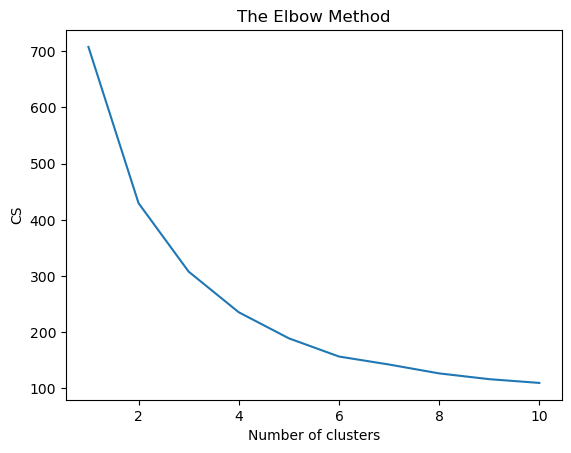

In [37]:
cs = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters = i, init = 'k-means++', max_iter = 300, n_init = 10, random_state = 0)
    kmeans.fit(X_scaled)
    cs.append(kmeans.inertia_)
plt.plot(range(1, 11), cs)
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('CS')
plt.show()

In [38]:
kmeans = KMeans(n_clusters=2, n_init = 10,random_state=0)
kmeans.fit(X_scaled)
labels = kmeans.labels_
# check how many of the samples were correctly labeled
correct_labels = sum(y == labels)
print("Result: %d out of %d samples were correctly labeled." % (correct_labels, y.size))
print('Accuracy score: {0:0.2f}'. format(correct_labels/float(y.size)))

Result: 617 out of 2556 samples were correctly labeled.
Accuracy score: 0.24


In [39]:
kmeans = KMeans(n_clusters=3, n_init = 10,random_state=0)
kmeans.fit(X_scaled)
labels = kmeans.labels_
# check how many of the samples were correctly labeled
correct_labels = sum(y == labels)
print("Result: %d out of %d samples were correctly labeled." % (correct_labels, y.size))
print('Accuracy score: {0:0.2f}'. format(correct_labels/float(y.size)))

Result: 401 out of 2556 samples were correctly labeled.
Accuracy score: 0.16


In [40]:
X_scaled["cluster"] = kmeans.predict(X_scaled)
kmeans.fit(X_test_scaled)
X_test_scaled["cluster"] = kmeans.predict(X_test_scaled)

In [41]:
X_cd = kmeans.fit_transform(X_scaled)
X_cd = pd.DataFrame(X_cd, columns=[f"Centroid_{i}" for i in range(X_cd.shape[1])])
X_test_cd = kmeans.fit_transform(X_test_scaled)
X_test_cd = pd.DataFrame(X_test_cd, columns=[f"Centroid_{i}" for i in range(X_test_cd.shape[1])])

In [42]:
X = X.join(X_cd)
#X_test = X_test.join(X_test_cd)
#X["cluster"] = X_scaled["cluster"]
#X_test["cluster"] = X_test_scaled["cluster"]

In [43]:
X_cd.dtypes

Centroid_0    float64
Centroid_1    float64
Centroid_2    float64
dtype: object

In [44]:
X.shape

(2556, 17)

In [45]:
X

,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed,year,time,"sin(1,freq=YE-DEC)","cos(1,freq=YE-DEC)",Centroid_0,Centroid_1,Centroid_2
2013-01-01 00:00:00,1025.9,19.9,18.3,16.8,13.1,72.0,49.0,9.3,80.0,26.3,1,0,0.000000,1.000000,NaN,NaN,NaN
2013-01-02 00:00:00,1022.0,21.7,18.9,17.2,15.6,81.0,83.0,0.6,50.0,15.3,1,1,0.017213,0.999852,NaN,NaN,NaN
2013-01-03 00:00:00,1019.7,20.3,19.3,18.0,18.4,95.0,91.0,0.0,40.0,14.2,1,2,0.034422,0.999407,NaN,NaN,NaN
2013-01-04 00:00:00,1018.9,22.3,20.6,19.1,18.8,90.0,88.0,1.0,50.0,16.9,1,3,0.051620,0.998667,NaN,NaN,NaN
2013-01-05 00:00:00,1015.9,21.3,20.7,20.2,19.9,95.0,81.0,0.0,40.0,13.7,1,4,0.068802,0.997630,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2019-12-27 00:00:00,1014.6,23.2,20.6,19.1,19.9,97.0,88.0,0.1,40.0,22.1,7,2551,-0.085965,0.996298,NaN,NaN,NaN
2019-12-28 00:00:00,1012.4,17.2,17.3,16.3,15.3,91.0,88.0,0.0,50.0,35.3,7,2552,-0.068802,0.997630,NaN,NaN,NaN
2019-12-29 00:00:00,1013.3,19.0,16.3,14.3,12.6,79.0,79.0,5.0,40.0,32.9,7,2553,-0.051620,0.998667,NaN,NaN,NaN
2019-12-30 00:00:00,1022.3,16.4,15.2,13.8,14.7,92.0,93.0,0.1,40.0,18.0,7,2554,-0.034422,0.999407,NaN,NaN,NaN
